In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [ ]:
df=pd.read_csv(r"C:\Users\SHILA\OneDrive\Desktop\PYTHON\ML_practiceDays\Datasets\Titanic-Dataset.csv", usecols=['Age','Fare','Survived'])
df.sample(2)

,Survived,Age,Fare
480,0,9.0,46.9
53,1,29.0,26.0


In [3]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [4]:
df.sample(5)

,Survived,Age,Fare
750,1,4.0,23.0000
278,0,7.0,29.1250
427,1,19.0,26.0000
141,1,22.0,7.7500
255,1,29.0,15.2458


In [5]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [8]:
xtrain, xtest, ytrain, ytest=train_test_split(x, y, test_size=0.2, random_state=42)

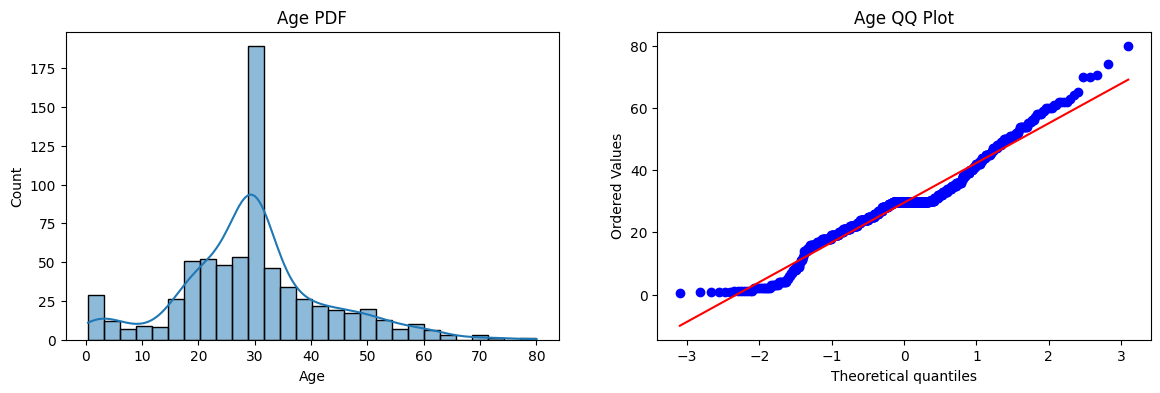

In [9]:
plt.figure(figsize=(14,4)) # (width, height)
plt.subplot(121) # no. of row, col & index of the subplot
sns.histplot(xtrain['Age'], kde=True)
plt.title("Age PDF") # probability density function

plt.subplot(122)
stats.probplot(xtrain['Age'],dist='norm',plot=plt) # how much data align on the best fitted line
plt.title("Age QQ Plot")

plt.show()

Text(0.5, 1.0, 'Fare QQ Plot')

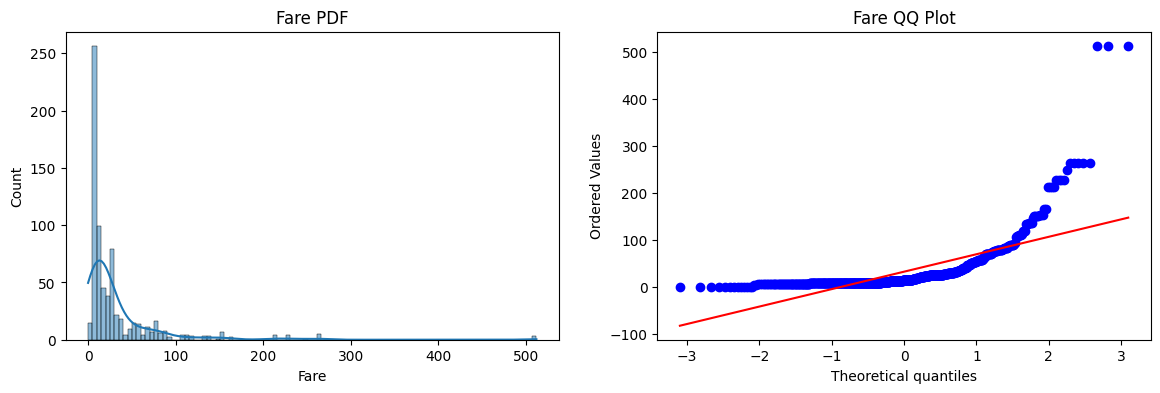

In [10]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(xtrain['Fare'], kde=True)
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(xtrain['Fare'],dist='norm',plot=plt)
plt.title("Fare QQ Plot")

In [11]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

In [12]:
clf1.fit(xtrain,ytrain)
clf2.fit(xtrain,ytrain)

ypred1=clf1.predict(xtest)
ypred2=clf2.predict(xtest)

In [13]:
print(f"Accuracy LR : {accuracy_score(ytest, ypred1)}")
print(f"Accuracy DT : {accuracy_score(ytest, ypred2)}")

Accuracy LR : 0.6480446927374302
Accuracy DT : 0.6759776536312849


In [14]:
trf=FunctionTransformer(func=np.log1p) # log1p adds 1 to output log val 

In [15]:
xtrain_transformed=trf.fit_transform(xtrain)
xtest_transformed=trf.transform(xtest)

In [16]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

In [17]:
clf1.fit(xtrain_transformed,ytrain)
clf2.fit(xtrain_transformed,ytrain)

ypred1=clf1.predict(xtest)
ypred2=clf2.predict(xtest)

print(f"Accuracy LR : {accuracy_score(ytest, ypred1)}")
print(f"Accuracy DT : {accuracy_score(ytest, ypred2)}")

Accuracy LR : 0.7374301675977654
Accuracy DT : 0.5921787709497207


In [18]:
xtransformed=trf.fit_transform(x)

clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

print(f"LR : {np.mean(cross_val_score(clf1,xtransformed,y,scoring='accuracy',cv=10))}")
print(f"DT : {np.mean(cross_val_score(clf2,xtransformed,y,scoring='accuracy',cv=10))}")

LR : 0.678027465667915
DT : 0.6610736579275905


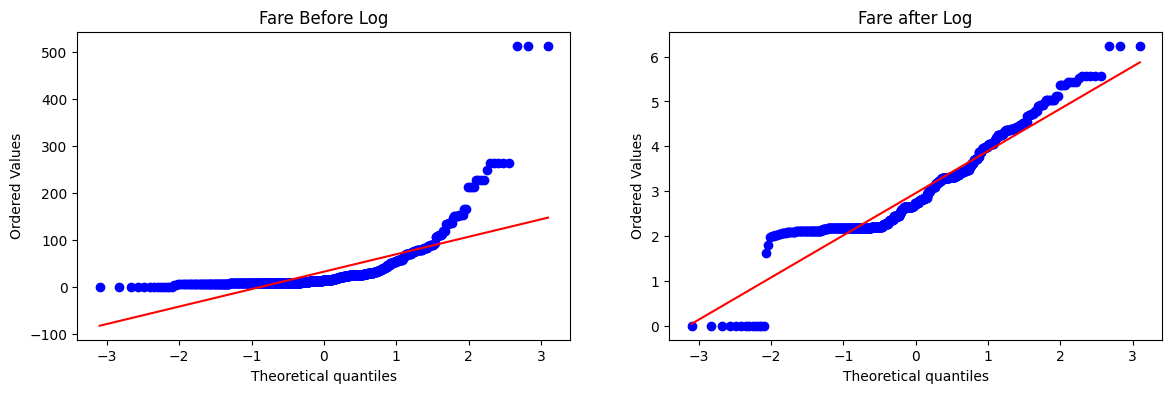

In [19]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(xtrain['Fare'],dist='norm',plot=plt)
plt.title("Fare Before Log")

plt.subplot(122)
stats.probplot(xtrain_transformed['Fare'],dist='norm',plot=plt)
plt.title("Fare after Log")

plt.show()

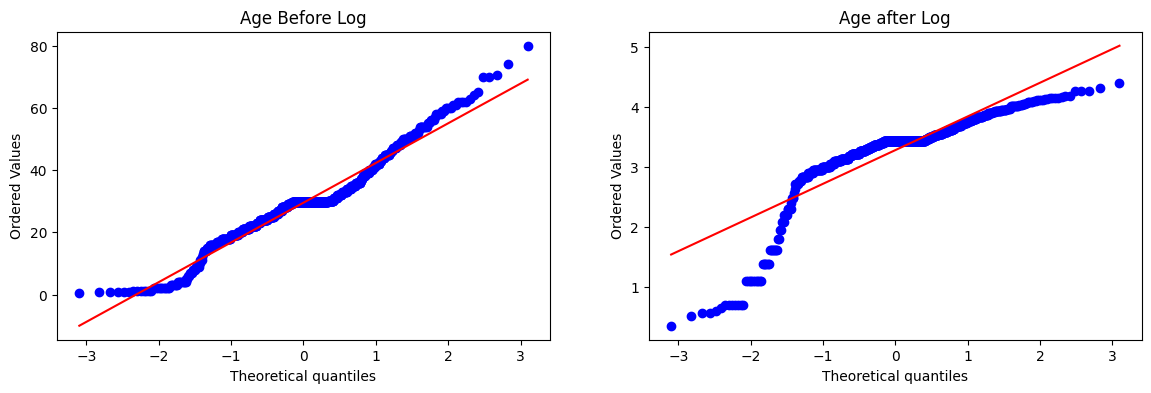

In [20]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(xtrain['Age'],dist='norm',plot=plt)
plt.title("Age Before Log")

plt.subplot(122)
stats.probplot(xtrain_transformed['Age'],dist='norm',plot=plt)
plt.title("Age after Log")

plt.show()

In [21]:
trf2=ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')
xtrain_transformed=trf2.fit_transform(xtrain)
xtest_transformed=trf2.transform(xtest)

In [22]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

clf1.fit(xtrain_transformed,ytrain)
clf2.fit(xtrain_transformed,ytrain)

ypred1=clf1.predict(xtest_transformed)
ypred2=clf2.predict(xtest_transformed)

In [23]:
print(f"Accuracy LR : {accuracy_score(ytest, ypred1)}")
print(f"Accuracy DT : {accuracy_score(ytest, ypred2)}")

Accuracy LR : 0.6703910614525139
Accuracy DT : 0.664804469273743


In [24]:
xtrain_transformed=trf2.fit_transform(x)

clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

print(f"LR : {np.mean(cross_val_score(clf1,xtrain_transformed,y,scoring='accuracy',cv=10))}")
print(f"LR : {np.mean(cross_val_score(clf2,xtrain_transformed,y,scoring='accuracy',cv=10))}")

LR : 0.6712609238451936
LR : 0.6599625468164794


In [25]:
def apply_transform(transform):
    x=df.iloc[:,1:3]
    y=df.iloc[:,0]

    trf1=ColumnTransformer([
        ('log',FunctionTransformer(transform),['Fare'])
    ],remainder='passthrough')

    xtrans=trf1.fit_transform(x)
    clf1=LogisticRegression()

    print(f"Accuracy : {np.mean(cross_val_score(clf1,xtrans,y,scoring='accuracy',cv=10))}")

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(x['Fare'],dist='norm',plot=plt)
    plt.title("Fare Before Transform")

    plt.subplot(122)
    stats.probplot(xtrans[:, 0],dist='norm',plot=plt)
    plt.title("Fare After Transform")

    plt.show()


Accuracy : 0.6431335830212235


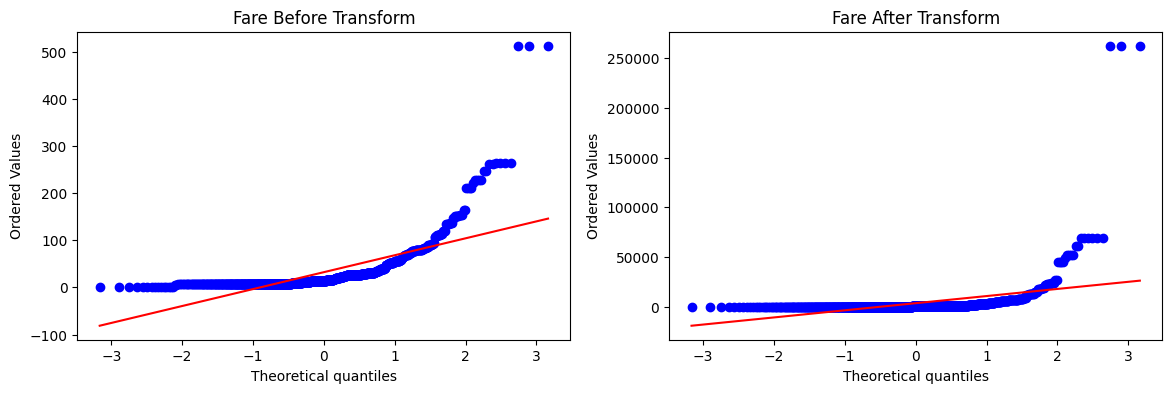

In [26]:
apply_transform(lambda x: x**2)

Accuracy : 0.6195131086142323


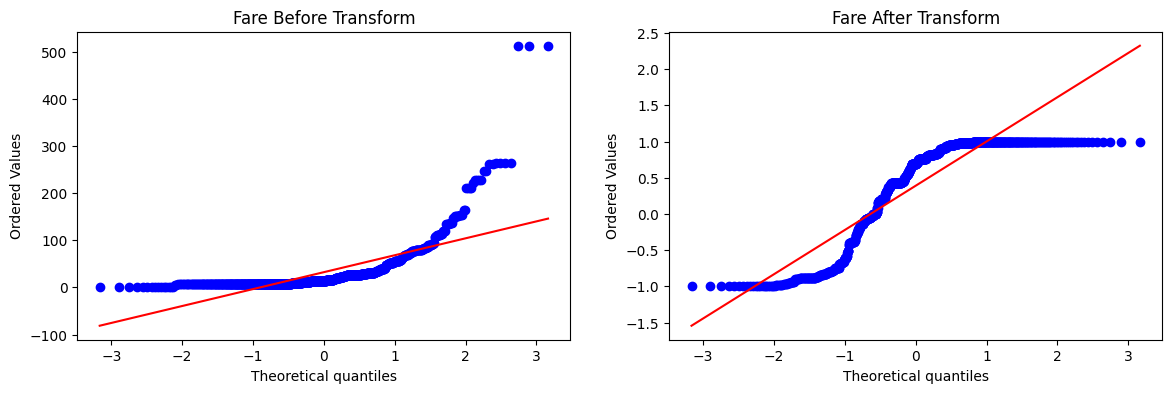

In [27]:
apply_transform(np.sin)